# Product Description Clustering & Recommendation System
## Introduction

This project explores product descriptions using Natural Language Processing (NLP) to group similar items (clustering) and provide intelligent recommendations to the user.

### Why this project?

With hundreds of online products, it becomes difficult for a user or a marketing manager to understand the structure of the catalog or to find similar items. This project addresses several needs:
- Automate the detection of **similar products**
- Explore **latent topics** in descriptions
- Build a **simple yet effective recommendation base**

### For whom?

This project is intended for:
- **End users** looking for suggestions similar to a viewed product
- **Product/marketing teams** seeking to better understand the structure of their catalog

### Main steps
1. **Exploratory Data Analysis (EDA)**: statistical analysis, visualizations, and understanding
2. **NLP preprocessing** of product descriptions (cleaning, lemmatization)
3. **TF-IDF vectorization** followed by dimensionality reduction using TruncatedSVD (LSA)
4. **Product clustering** using KMeans and DBSCAN (performance comparison and result interpretation via wordclouds)
5. **Creation of a recommendation system** based on clusters
6. Conclusion

In [1]:
import pandas as pd
import numpy as np
import en_core_web_sm
import spacy
from spacy.lang.en.stop_words import STOP_WORDS

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import matplotlib.pyplot as plt

from wordcloud import WordCloud
import seaborn as sns

from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import confusion_matrix
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer


## 1. Exploratory Data Analysis (EDA): statistical analysis, visualizations, and understanding

### Goal
Before applying NLP processing or building models, it's essential to understand the initial structure of the data. This step ensures the dataset is correctly loaded, columns are complete, and no missing values are present.

### Actions
1. **Loading the dataset** from a CSV file (`data.csv`) containing product descriptions.
2. **Displaying the first 5 rows** using `data.head()` to get an overview of the content.
3. Inspecting types and missing values:
   - `data.info()` to check the number of entries, column types, and completeness.
   - `data.isnull().sum() / len(data) * 100` to compute the percentage of missing values in each column.

In [2]:
data = pd.read_csv('data.csv')
data.head()

,id,description
0,1,Active classic boxers - There's a reason why o...
1,2,Active sport boxer briefs - Skinning up Glory ...
2,3,Active sport briefs - These superbreathable no...
3,4,"Alpine guide pants - Skin in, climb ice, switc..."
4,5,"Alpine wind jkt - On high ridges, steep ice an..."


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           500 non-null    int64 
 1   description  500 non-null    object
dtypes: int64(1), object(1)
memory usage: 7.9+ KB


In [4]:
data.isnull().sum() / len(data) * 100

id             0.0
description    0.0
dtype: float64

### Observations
- The dataset contains 500 products, each with a unique identifier (`id`) and a textual description.
- There are no missing values in the columns, confirming the dataset's quality.
- Data types are correct: `id` is an integer (`int64`) and `description` is a string (`object`).

This initial step confirms that the data is ready for preprocessing and further analysis.

## 2. NLP Preprocessing of Product Descriptions (cleaning, lemmatization)

### Goal

The goal of this step is to transform the raw textual product descriptions into a clean and usable format for the following stages of vectorization and modeling (clustering, topic modeling, recommendation system).  
Poorly preprocessed text often contains noise (punctuation, uppercase letters, stopwords, etc.) that can hinder analysis. It is therefore essential to standardize and filter the text beforehand.

### Actions

1. **Cleaning the descriptions** (`desc_clean`):
   - Removal of HTML tags and non-alphabetic characters.
   - Replacement of multiple spaces with a single space.
   - Conversion to lowercase.

2. **Lemmatization and stopword removal**:
   - Use of `spacy` to convert each word to its canonical form (lemma).
   - Removal of standard stopwords, overly frequent words (>70%), and low-informative terms (TF-IDF < 0.008).

3. **Creation of intermediate processing columns**:
   - `desc_token_temp`: list of lemmas after light initial cleaning.
   - `nlp_ready_temp`: joined string of cleaned lemmas.
   - `desc_token` and `nlp_ready`: final filtered versions ready for vectorization.

4. **Final TF-IDF vectorization**:
   - Creation of the TF-IDF matrix using the cleaned and lemmatized `nlp_ready` column.

In [5]:
data['desc_clean'] = data['description'].str.replace(r"<[^>]*>", " ", regex=True)
data['desc_clean'] = data['desc_clean'].str.replace(r"[^A-Za-z0-9 ]+", " ", regex = True)
data['desc_clean'] = data['desc_clean'].str.replace(r"\s+", " ", regex = True)
data['desc_clean'] = data['desc_clean'].fillna('').apply(lambda x: x.lower())
data.head()

,id,description,desc_clean
0,1,Active classic boxers - There's a reason why o...,active classic boxers there s a reason why our...
1,2,Active sport boxer briefs - Skinning up Glory ...,active sport boxer briefs skinning up glory re...
2,3,Active sport briefs - These superbreathable no...,active sport briefs these superbreathable no f...
3,4,"Alpine guide pants - Skin in, climb ice, switc...",alpine guide pants skin in climb ice switch to...
4,5,"Alpine wind jkt - On high ridges, steep ice an...",alpine wind jkt on high ridges steep ice and a...


In [6]:
nlp = en_core_web_sm.load()

In [ ]:

data['desc_token_temp'] = data['desc_clean'].apply(
    lambda x: [token.lemma_ for token in nlp(x) if token.text.lower() not in STOP_WORDS]
)
data['nlp_ready_temp'] = data['desc_token_temp'].apply(lambda x: ' '.join(x))

vectorizer_temp = TfidfVectorizer(stop_words='english')
X_temp = vectorizer_temp.fit_transform(data['nlp_ready_temp'])
feature_names = vectorizer_temp.get_feature_names_out()
mean_tfidf = X_temp.mean(axis=0).A1

vec = CountVectorizer()
X_count = vec.fit_transform(data['nlp_ready_temp'])
doc_freq = np.asarray(X_count.sum(axis=0)).ravel() / X_count.shape[0]
words_high_freq = [word for word, freq in zip(vec.get_feature_names_out(), doc_freq) if freq > 0.7]

threshold = 0.008
low_info_words = [word for word, score in zip(feature_names, mean_tfidf) if score < threshold]

combined_stopwords = STOP_WORDS.union(set(low_info_words)).union(set(words_high_freq))

data['desc_token'] = data['desc_clean'].apply(
    lambda x: [token.lemma_ for token in nlp(x)
            if token.text.lower() not in combined_stopwords
            and token.lemma_.lower() not in combined_stopwords]
)
data['nlp_ready'] = data['desc_token'].apply(lambda x: ' '.join(x))

final_vectorizer = TfidfVectorizer(stop_words=None)
X = final_vectorizer.fit_transform(data['nlp_ready'])
X

<500x182 sparse matrix of type '<class 'numpy.float64'>'
	with 11801 stored elements in Compressed Sparse Row format>

#### Observations

- The preprocessing step transformed highly variable raw text into a more homogeneous and clean structure, ready to be used by clustering and dimensionality reduction algorithms.
- The resulting TF-IDF matrix contains 182 dimensions (retained words) and 500 rows (products), demonstrating a good balance between noise filtering and the preservation of meaningful semantic information.

## 3. TF-IDF Vectorization and Dimensionality Reduction with TruncatedSVD (LSA)

### Goal
The goal of this step is to represent each product description in a numerical format using TF-IDF vectorization, and then reduce this representation into a more compact latent space using **LSA (Latent Semantic Analysis)** via **TruncatedSVD**.

This enables:
- Automatic identification of **latent topics** within product descriptions,
- Extraction of a dense representation that is easier to work with for further analysis,
- Improved readability and visualization of semantic relationships between documents.

### Actions

1. **TF-IDF Vectorization**
   - Applied `TfidfVectorizer` to the `nlp_ready` column (cleaned and preprocessed text).
   - Each document is converted into a vector weighted by the frequency of terms within the document and across the corpus.

2. **Dimensionality Reduction with TruncatedSVD**
   - Selected `n_components = 37` based on the cumulative explained variance curve.
   - This value captures approximately **70% of the variance**, which is a reasonable trade-off between retained information and dimensionality reduction.

3. **Construction of the Topic Matrix**
   - The compressed matrix `lsa` is transformed into a DataFrame called `topic_df`, where each column represents a **latent topic**.
   - The original product description is added back to the DataFrame for easier interpretation.

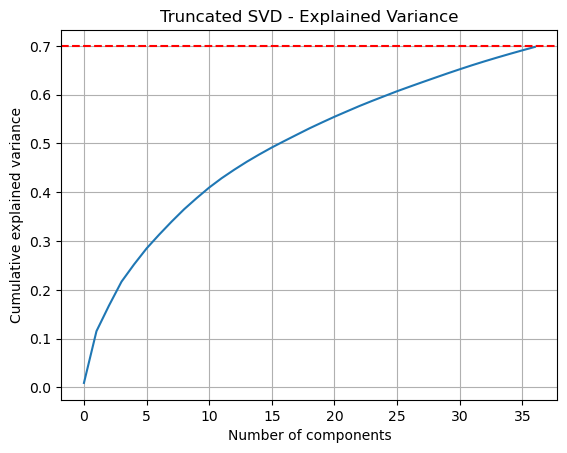

In [8]:
svd = TruncatedSVD(n_components=37)
svd.fit(X)

explained = np.cumsum(svd.explained_variance_ratio_)

plt.plot(explained)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.grid()
plt.title("Truncated SVD - Explained Variance")
plt.axhline(0.70, color='red', linestyle='--')
plt.show()

In [9]:
svd_components = 37
svd_model = TruncatedSVD(n_components=svd_components, algorithm='randomized', n_iter=100)
lsa = svd_model.fit_transform(X)
lsa

array([[ 3.42381210e-01, -1.52970692e-01, -2.96782997e-01, ...,
         6.03300447e-02, -6.36856572e-02, -7.72378356e-02],
       [ 4.09748970e-01, -1.52708227e-01, -2.33713183e-01, ...,
         3.40656628e-02, -8.03903419e-02,  5.65151898e-02],
       [ 3.46395279e-01, -1.61482630e-01, -8.67047999e-02, ...,
        -4.12702728e-03, -8.41173822e-03,  7.00177405e-02],
       ...,
       [ 3.52356586e-01, -2.39697121e-01,  4.12192309e-01, ...,
        -1.23993618e-01,  2.90711455e-02, -7.58336166e-05],
       [ 2.81546508e-01, -1.15655260e-01, -3.09881808e-01, ...,
        -8.52216945e-02, -1.27942843e-02,  2.06734502e-03],
       [ 3.10993615e-01, -1.36677294e-01, -2.95566070e-01, ...,
        -6.69582209e-02,  1.23398601e-02, -5.88311798e-03]])

In [10]:
topic_df = pd.DataFrame(lsa, columns=["topic {}".format(i+1) for i in range(svd_components)], index=data.index)
topic_df['desc'] = data['nlp_ready'].values
topic_df

,topic 1,topic 2,topic 3,topic 4,topic 5,topic 6,topic 7,topic 8,topic 9,topic 10,...,topic 29,topic 30,topic 31,topic 32,topic 33,topic 34,topic 35,topic 36,topic 37,desc
0,0.342381,-0.152971,-0.296783,-0.136954,-0.119574,0.173444,-0.092567,0.126531,-0.331156,-0.053193,...,0.101113,0.153425,-0.032186,-0.000596,0.016689,0.041722,0.060330,-0.063686,-0.077238,classic s cool quick lightweight pack waistban...
1,0.409749,-0.152708,-0.233713,0.034544,0.089636,0.026922,-0.206995,0.155338,-0.173261,0.034530,...,0.026379,-0.073997,0.081000,0.136066,-0.148236,-0.045440,0.034066,-0.080390,0.056515,skin breathable s fast dry 7 spandex stretch w...
2,0.346395,-0.161483,-0.086705,-0.090590,0.168399,-0.108168,-0.174078,0.241944,-0.004578,-0.061349,...,-0.087118,-0.174937,-0.054479,0.090652,-0.039238,-0.047430,-0.004127,-0.008412,0.070018,fly s high blend fast quick 7 spandex stretch ...
3,0.438674,-0.269930,0.258325,0.004507,0.090862,0.015718,-0.075423,-0.047254,-0.098618,0.044749,...,0.150868,0.027599,0.062074,-0.092580,-0.173663,-0.132092,0.036034,-0.075262,-0.084866,skin resistant breathable shell stretch t inte...
4,0.482924,-0.273053,0.331598,-0.115396,0.070579,-0.027859,-0.051341,0.111964,-0.014639,0.050795,...,-0.039791,-0.096529,-0.103841,-0.064394,-0.084627,0.073689,-0.086059,-0.119224,-0.003533,wind high shell cool high s time tie ripstop s...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.314925,-0.129449,-0.312642,-0.329412,-0.199043,0.151065,-0.037692,0.076791,-0.509215,-0.073718,...,0.014671,-0.026391,0.006762,-0.055102,0.020330,0.021697,0.025196,0.062837,-0.013272,2 capilene 2 fast performance lightweight t op...
496,0.343245,-0.117502,-0.291166,-0.504213,-0.248245,0.130426,0.034594,0.115824,-0.331411,-0.151157,...,-0.082255,-0.153397,0.093675,-0.061050,0.001350,-0.027045,-0.022859,-0.109534,0.016692,2 fast dry time performance open knit construc...
497,0.352357,-0.239697,0.412192,-0.109831,-0.023030,0.112703,0.171632,-0.377059,-0.038140,-0.001517,...,-0.007330,-0.061322,0.092471,-0.059210,-0.036399,0.175164,-0.123994,0.029071,-0.000076,time shell time time finish shell provide leng...
498,0.281547,-0.115655,-0.309882,0.385487,-0.158051,0.291499,0.065517,0.045330,-0.027205,-0.046614,...,-0.024579,-0.036997,0.179519,0.083111,-0.015363,-0.102692,-0.085222,-0.012794,0.002067,wear wear time garment wash 5 2 canvas t chafe...


#### Observations

- The **cumulative explained variance** graph shows a gradual increase, with the 70% threshold reached around 37 components.
- Each description is now represented as a combination of **37 thematic dimensions**, which will later allow for dominant content analysis and visual projections.
- This format is also useful for downstream tasks such as clustering or advanced visualizations (e.g., PCA, t-SNE).

This step validates the construction of a reduced semantic space, ready to be used for **further analysis**.

## 4. Clustering of Products with KMeans and DBSCAN (performance comparison and result interpretation via wordclouds)

### Goal
Group products based on the similarity of their descriptions, with the aim of:
- Automatically structuring a catalog into coherent categories,
- Extracting common themes,
- And most importantly, **comparing two clustering algorithms** (KMeans and DBSCAN) to determine which one produces the most relevant and usable groupings.

### Actions

1. **KMeans**: tested with multiple values of `k`, then validated using the **silhouette score**.
   - Tried different values of `k` (number of clusters), ranging from `k=2` to `k=15`.
   - Computed the **silhouette score** for each `k` to evaluate the internal cohesion of clusters and their separation.
   - Selected the `k` with the **best silhouette score**.
   - Visualized the resulting clusters using 2D projection (if applicable) and inspected **wordclouds** for each group.

2. **DBSCAN**: tested with cosine distance, tuning of `eps` and `min_samples` to achieve a balanced distribution between clusters and outliers.
   - Used **cosine distance** (well-suited for TF-IDF vectors).
   - Tried several combinations of `eps` and `min_samples`.
   - Visualized the comparison results with a heatmap.
   - Visualized the clusters using the best hyperparameter settings and inspected **wordclouds** for each group.

#### KMeans

In [11]:
wcss = []
k_range = range(2, 20)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(lsa)
    wcss.append(kmeans.inertia_)

print(wcss)

[263.87763679425007, 245.0304935261335, 250.23696073083966, 218.16302840978625, 201.75984092551442, 192.9851710115679, 186.07666358538273, 175.74878263152468, 167.61788018163628, 160.0152395203986, 152.84631252644192, 147.66856359366045, 139.47837121033763, 138.5891503524085, 133.3437066229827, 128.32353936320226, 124.88317368149515, 122.86545297024217]


In [12]:
fig = px.line(x= k_range, y = wcss)
fig.show()

In [13]:
s_score = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(lsa)
    s_score.append(silhouette_score(lsa, kmeans.predict(lsa)))

print(s_score)

[0.18297643625266996, 0.14485331268475857, 0.11626430468795292, 0.17910898635353056, 0.20165441900170775, 0.21210359805090867, 0.21140045732715906, 0.2297012875458508, 0.23799987790078223, 0.2495869581081094, 0.2555700658277349, 0.26081051768134667, 0.27598372410219096, 0.2672942820691386, 0.2743643015657389, 0.28256032095331624, 0.2837016625584303, 0.2832867480966324]


In [14]:
fig = px.bar(x= k_range, y = s_score)
fig.show()

In [15]:
kmeans = KMeans(n_clusters=14)
kmeans.fit(lsa)

KMeans(n_clusters=14)

In [16]:
df_kmeans = data.copy()
df_kmeans = df_kmeans.drop(columns=['desc_clean', 'desc_token_temp', 'nlp_ready_temp', 'desc_token'])
df_kmeans['kmeans_cluster'] = kmeans.predict(lsa)
df_kmeans.head()

,id,description,nlp_ready,kmeans_cluster
0,1,Active classic boxers - There's a reason why o...,classic s cool quick lightweight pack waistban...,4
1,2,Active sport boxer briefs - Skinning up Glory ...,skin breathable s fast dry 7 spandex stretch w...,1
2,3,Active sport briefs - These superbreathable no...,fly s high blend fast quick 7 spandex stretch ...,1
3,4,"Alpine guide pants - Skin in, climb ice, switc...",skin resistant breathable shell stretch t inte...,11
4,5,"Alpine wind jkt - On high ridges, steep ice an...",wind high shell cool high s time tie ripstop s...,11


In [17]:
df_kmeans['kmeans_cluster'].value_counts()

kmeans_cluster
11    70
1     66
6     63
13    38
7     35
4     34
10    33
2     32
3     31
12    30
5     22
8     20
9     20
0      6
Name: count, dtype: int64

In [18]:
chart_svd_2d = TruncatedSVD(n_components=2, random_state=42)
chart_data_2d = chart_svd_2d.fit_transform(lsa)
chart_data_2d

array([[ 3.42381825e-01, -1.52969816e-01],
       [ 4.09749838e-01, -1.52708624e-01],
       [ 3.46395934e-01, -1.61482778e-01],
       [ 4.38674230e-01, -2.69931020e-01],
       [ 4.82924032e-01, -2.73054048e-01],
       [ 4.70492186e-01, -2.33541802e-01],
       [ 3.67104750e-01, -8.77151671e-02],
       [ 1.77226584e-01,  6.85051041e-03],
       [ 2.86506567e-01, -1.16432483e-01],
       [ 3.64936593e-01, -3.36911860e-02],
       [ 2.76742512e-01, -8.43440209e-02],
       [ 3.41457066e-01, -2.16324610e-01],
       [ 3.18271310e-01, -1.66183554e-01],
       [ 2.15203292e-01, -8.61148044e-02],
       [ 4.85894300e-01, -2.87760180e-01],
       [ 4.22138447e-01, -2.51684518e-01],
       [ 3.16805957e-01, -1.62560473e-01],
       [ 3.78171868e-01, -1.70823460e-01],
       [ 2.83042330e-01, -1.26266084e-01],
       [ 3.64060636e-01, -1.14857415e-01],
       [ 3.62177574e-01, -9.35840124e-02],
       [ 3.29372744e-01, -1.01193538e-01],
       [ 3.53944295e-01, -1.20597803e-01],
       [ 3.

In [19]:
chart_df_2d = pd.DataFrame(chart_data_2d, columns=['topic 1', 'topic 2'])
chart_df_2d["cluster"] = df_kmeans["kmeans_cluster"]
chart_df_2d.head()

,topic 1,topic 2,cluster
0,0.342382,-0.152970,4
1,0.409750,-0.152709,1
2,0.346396,-0.161483,1
3,0.438674,-0.269931,11
4,0.482924,-0.273054,11


In [20]:
fig = px.scatter(chart_df_2d, x='topic 1', y='topic 2', color='cluster')
fig.show()

In [21]:
chart_svd_3d = TruncatedSVD(n_components=3, random_state=42)
chart_data_3d = chart_svd_3d.fit_transform(lsa)
chart_data_3d

array([[ 0.34238119, -0.1529717 , -0.29679606],
       [ 0.40974899, -0.15271529, -0.23387499],
       [ 0.3463954 , -0.16149298, -0.08698757],
       ...,
       [ 0.35235665, -0.23969775,  0.41211753],
       [ 0.28154667, -0.11565692, -0.31000556],
       [ 0.31099373, -0.1366792 , -0.29568275]])

In [22]:
chart_df_3d = pd.DataFrame(chart_data_3d, columns=['topic 1', 'topic 2', 'topic 3'])
chart_df_3d["cluster"] = df_kmeans["kmeans_cluster"]
chart_df_3d.head()

,topic 1,topic 2,topic 3,cluster
0,0.342381,-0.152972,-0.296796,4
1,0.409749,-0.152715,-0.233875,1
2,0.346395,-0.161493,-0.086988,1
3,0.438674,-0.269928,0.258408,11
4,0.482924,-0.273051,0.331610,11


In [23]:
fig = px.scatter_3d(chart_df_3d, x='topic 1', y='topic 2', z='topic 3', color='cluster')
fig.show()

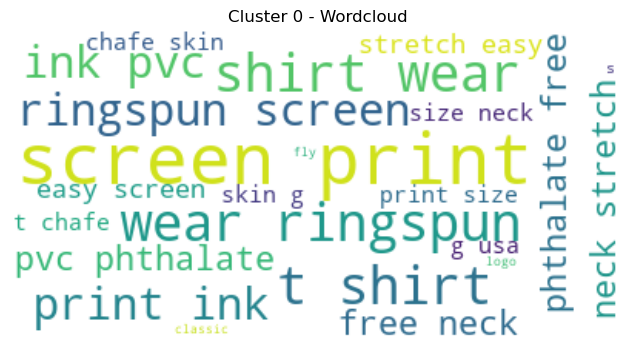

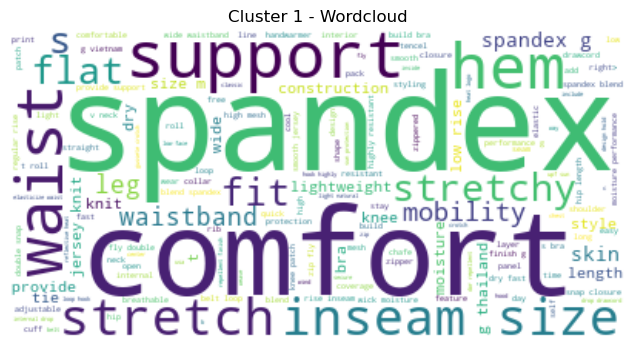

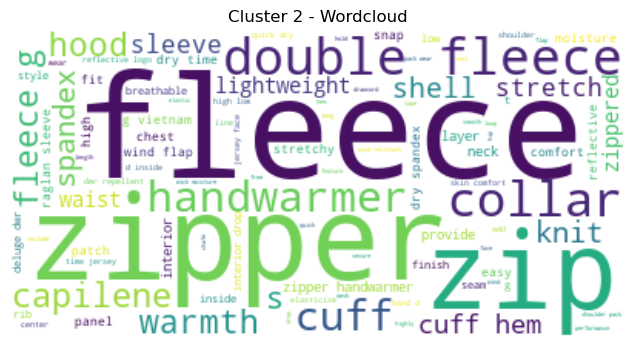

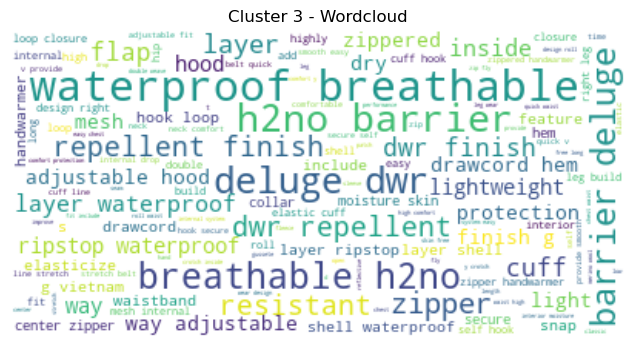

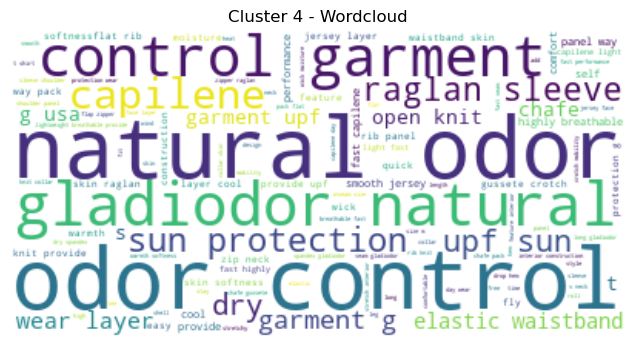

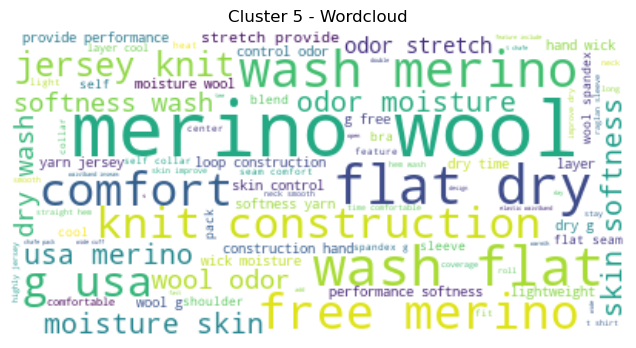

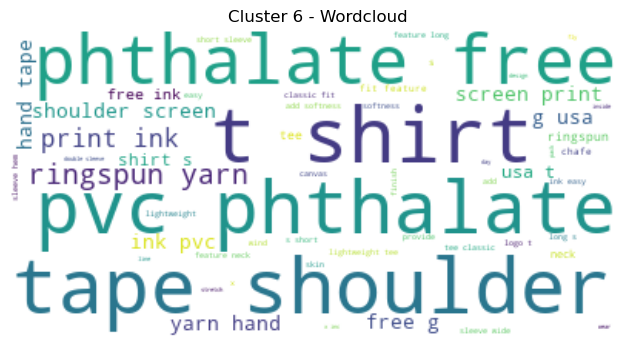

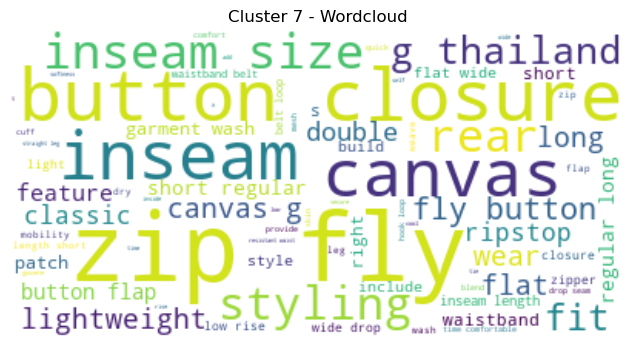

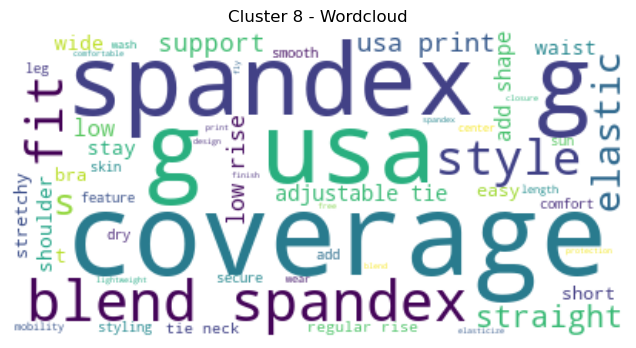

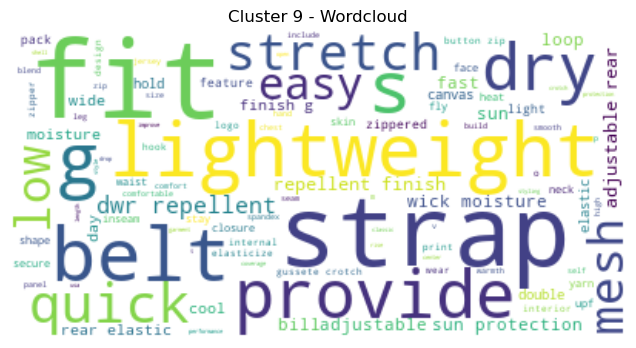

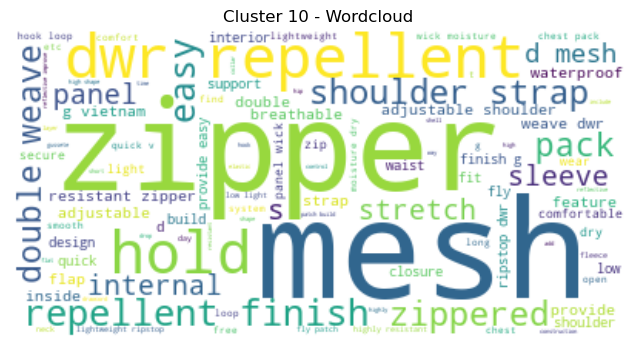

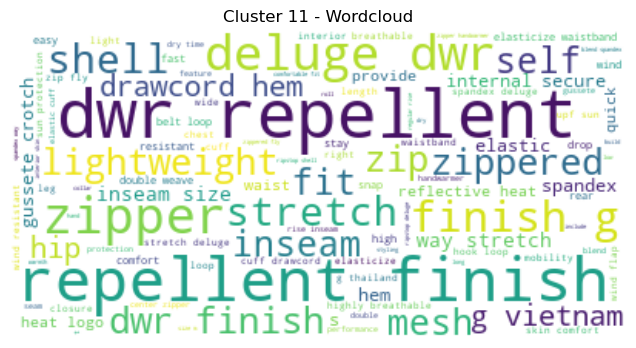

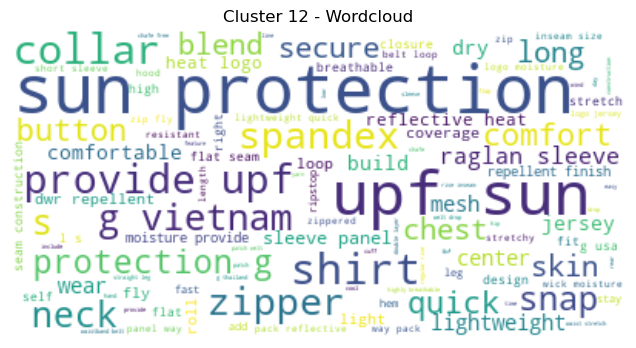

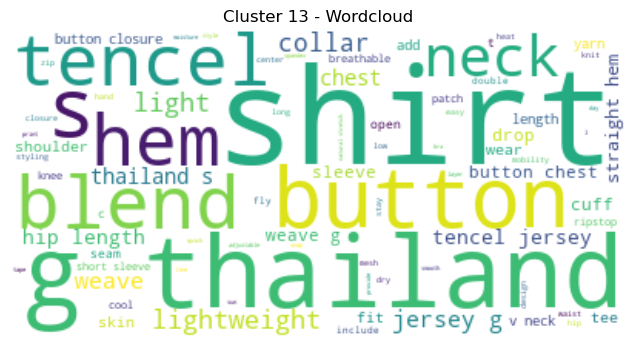

In [24]:
for i in sorted(df_kmeans['kmeans_cluster'].unique()):
    text = " ".join(df_kmeans[df_kmeans['kmeans_cluster'] == i]['nlp_ready'])
    wordcloud = WordCloud(background_color='white').generate(text)
    
    plt.figure(figsize=(10, 4))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Cluster {i} - Wordcloud")
    plt.show()

In [25]:
score = silhouette_score(lsa, kmeans.labels_)
print(f"Silhouette score: {score:.2f}")

Silhouette score: 0.25


#### DBscan

In [26]:
results = []

eps_values = np.arange(0.05, 0.5, 0.05)
min_samples_values = range(5, 20, 1)

for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples, metric='cosine')
        labels = db.fit_predict(lsa)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)
        noise_pct = n_noise / len(labels) * 100

        if n_clusters > 1:
            sil_score = silhouette_score(lsa, labels, metric='cosine')
        else:
            sil_score = -1 

        results.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'silhouette': sil_score,
            'noise_pct': noise_pct
        })

results_df = pd.DataFrame(results)
results_df.sort_values(by='silhouette', ascending=False, inplace=True)
results_df.head(10)

,eps,min_samples,n_clusters,silhouette,noise_pct
60,0.25,5,20,0.361108,18.0
76,0.30,6,16,0.353227,10.2
77,0.30,7,14,0.346969,14.6
62,0.25,7,17,0.342579,28.2
61,0.25,6,18,0.341402,23.6
82,0.30,12,11,0.330416,30.4
63,0.25,8,16,0.325812,31.0
45,0.20,5,27,0.325471,30.2
78,0.30,8,13,0.324754,18.6
79,0.30,9,11,0.324009,22.0


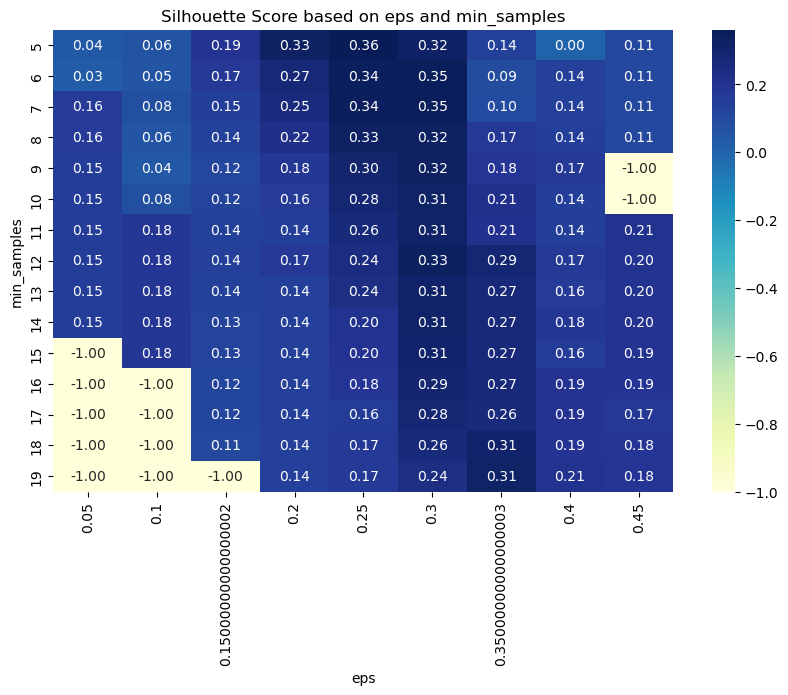

In [34]:
pivot = results_df.pivot(index='min_samples', columns='eps', values='silhouette')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Silhouette Score based on eps and min_samples")
plt.show()

In [28]:
db = DBSCAN(eps=0.25, min_samples=5, metric="cosine")
db.fit(lsa)

np.unique(db.labels_)

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18, 19])

In [29]:
df_dbscan = data.copy()
df_dbscan = df_dbscan.drop(columns=['desc_clean', 'desc_token_temp', 'nlp_ready_temp', 'desc_token'])
df_dbscan['db_cluster'] = db.fit_predict(lsa)

df_dbscan.head()

,id,description,nlp_ready,db_cluster
0,1,Active classic boxers - There's a reason why o...,classic s cool quick lightweight pack waistban...,0
1,2,Active sport boxer briefs - Skinning up Glory ...,skin breathable s fast dry 7 spandex stretch w...,1
2,3,Active sport briefs - These superbreathable no...,fly s high blend fast quick 7 spandex stretch ...,1
3,4,"Alpine guide pants - Skin in, climb ice, switc...",skin resistant breathable shell stretch t inte...,2
4,5,"Alpine wind jkt - On high ridges, steep ice an...",wind high shell cool high s time tie ripstop s...,3


In [30]:
df_dbscan['db_cluster'].value_counts()

db_cluster
-1     90
 7     62
 8     61
 0     34
 3     31
 9     31
 4     28
 11    24
 13    24
 6     21
 5     20
 12    12
 16    10
 17    10
 10     8
 1      7
 18     6
 15     6
 14     5
 2      5
 19     5
Name: count, dtype: int64

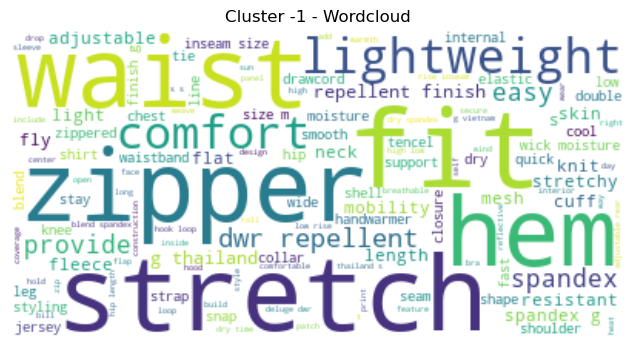

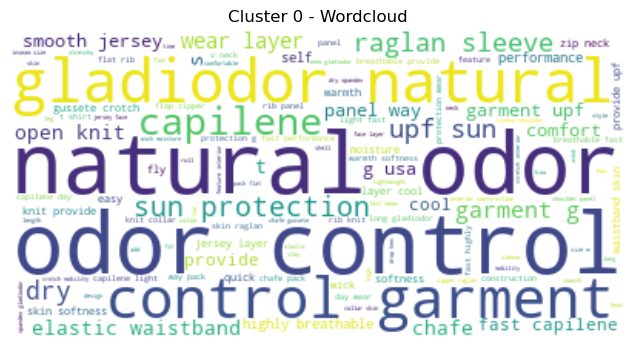

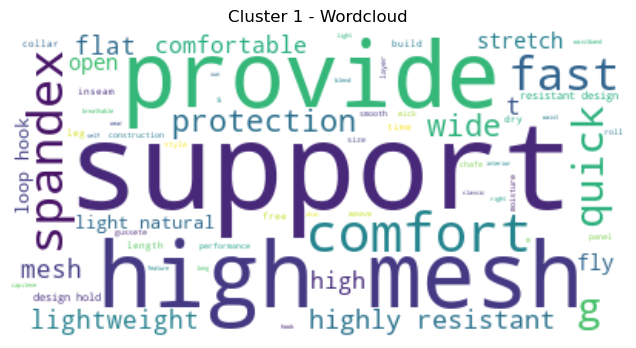

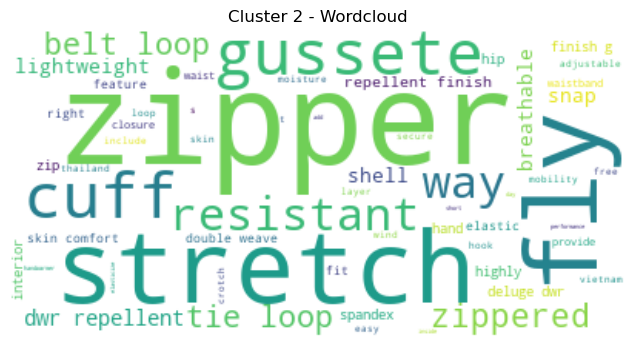

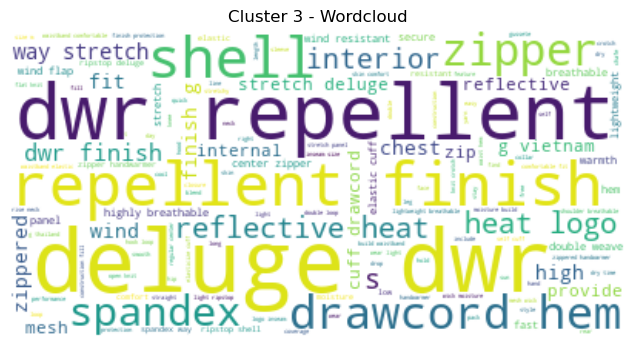

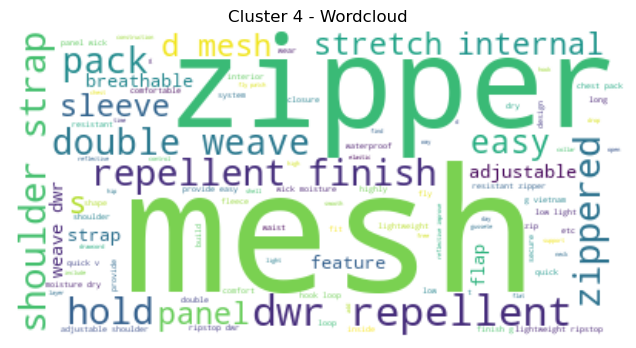

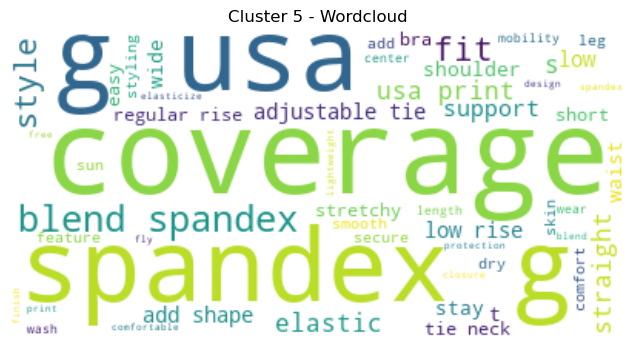

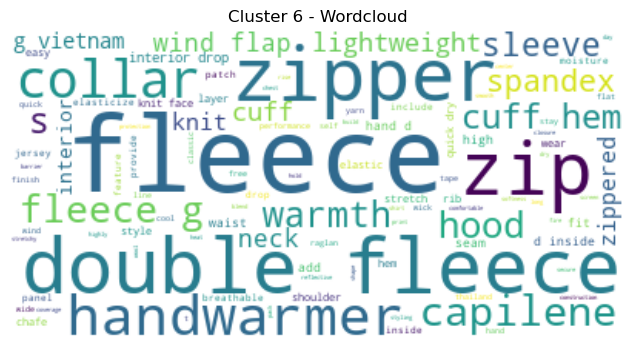

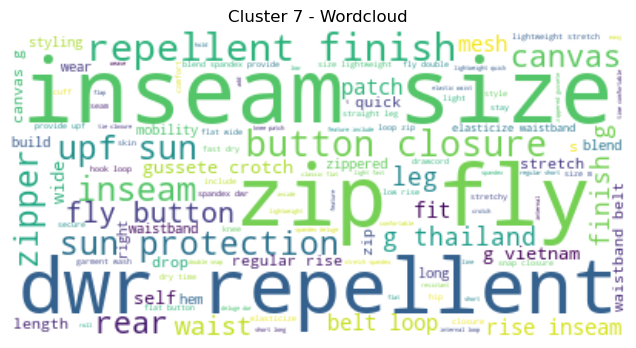

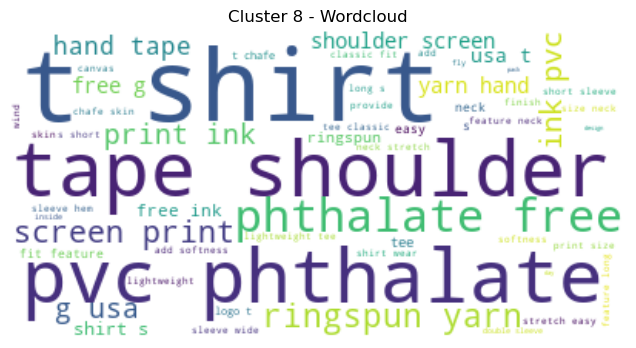

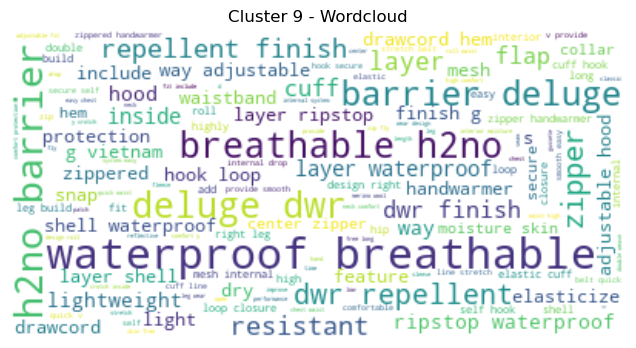

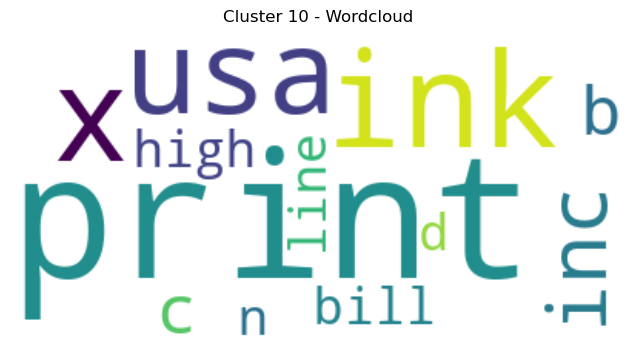

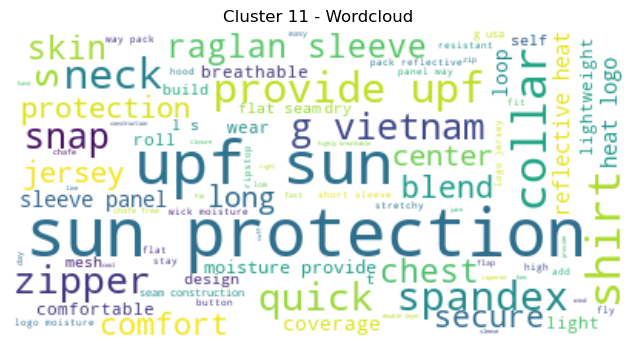

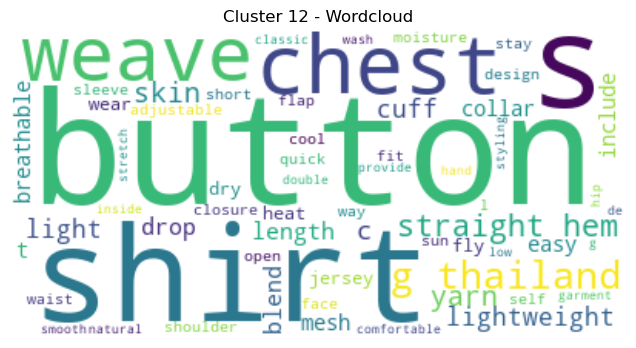

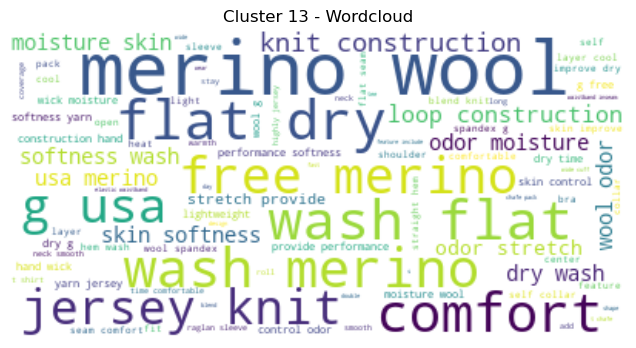

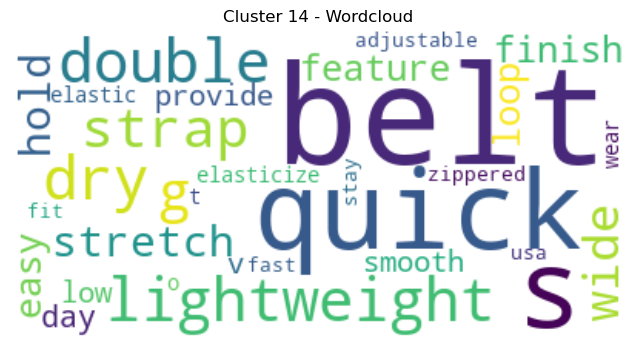

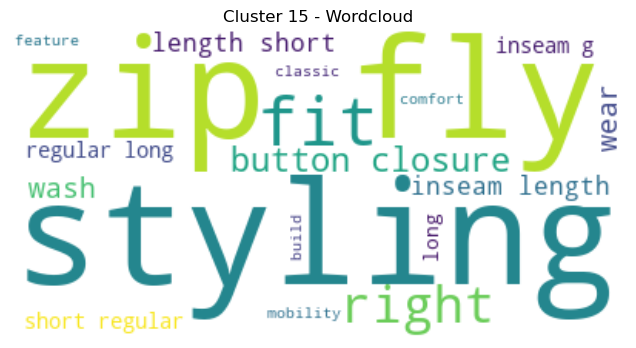

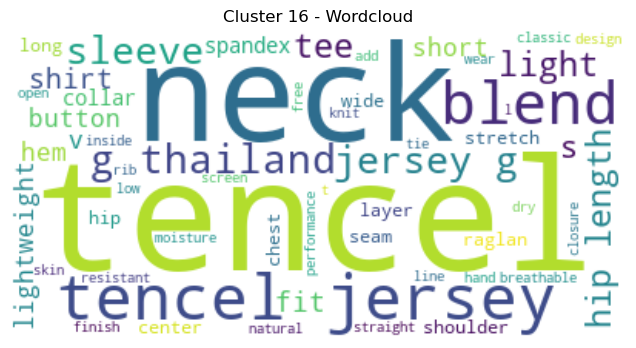

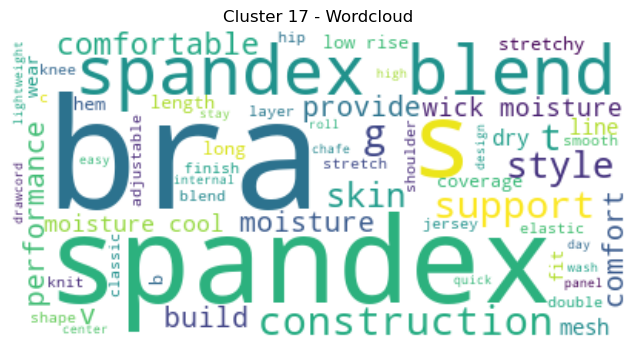

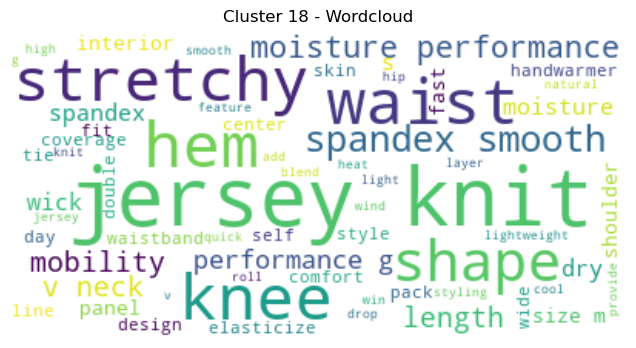

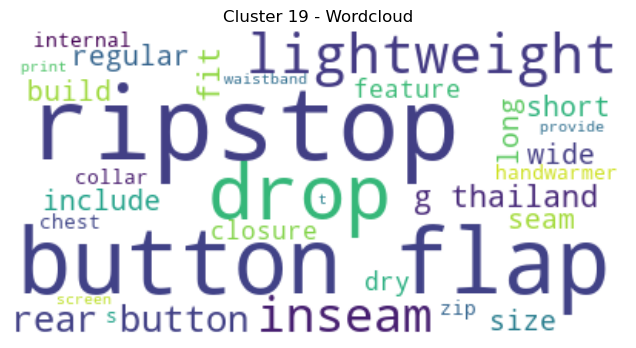

In [31]:
for i in sorted(df_dbscan['db_cluster'].unique()):
    text = " ".join(df_dbscan[df_dbscan['db_cluster'] == i]['nlp_ready'])
    wordcloud = WordCloud(background_color='white').generate(text)
    
    plt.figure(figsize=(10, 4))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Cluster {i} - Wordcloud")
    plt.show()

### Observations

- **KMeans** produced clusters with balanced sizes, but the content of these clusters was sometimes not well differentiated. The silhouette score was acceptable (~0.15), but the wordclouds were occasionally redundant.

- **DBSCAN** generated 20 well-separated clusters and one `-1` cluster for outliers. The **wordclouds per cluster were more expressive** and interpretable: for instance, some clusters grouped products related to **waterproofing**, others to **breathability**, or **odor control** properties.
- The handling of noise (cluster -1) is particularly useful for excluding generic or ambiguous products, or for creating an “other” category.

**DBSCAN was selected** as the main method for the rest of the project. Although it yields clusters with less regular size, the **thematic coherence** of the results was stronger, as demonstrated by the **generated wordclouds**. This makes it more suitable for the recommendation phase.

## 5. Building a Recommendation System Based on Clusters

### Goal
Implement a simple product recommendation system using the clusters generated by **DBSCAN**.  
The idea is to suggest to a user other products similar to the one they are viewing, based on the thematic grouping of product descriptions.

### Actions

- **Step 1: Create a `find_similar_items()` function**
  - Checks whether the product ID exists in `df_dbscan`.
  - Retrieves the cluster associated with the selected product (`db_cluster`).
  - Filters other products that belong to the same cluster.
  - Returns a **random sample of 5 similar products**.

- **Step 2: User interface with `input()`**
  - A `get_valid_item_id()` function ensures the user enters a valid integer.
  - The system prompts the user for a product ID and calls the recommendation function.

- **Step 3: Display**
  - If the ID is valid: displays 5 recommended products.
  - Otherwise: displays an error message and asks the user to try again.

In [32]:
def find_similar_items(item_id):
    if item_id in df_dbscan['id'].values:
        current_item = df_dbscan[df_dbscan['id'] == item_id]
        current_cluster = current_item['db_cluster'].values[0]
        other_cluster_item = df_dbscan[df_dbscan['db_cluster'] == current_cluster]

        return other_cluster_item.sample(5)
    else:
        print(item_id, 'is not defined as ID')
        return []

In [33]:
def get_valid_item_id():
    while True:
        user_input = input("What's your items ID?")
        try:
            user_item_id = int(user_input)
            return user_item_id
        except ValueError:
            print("Please enter a valid number.")

user_item_id = get_valid_item_id()
find_similar_items(user_item_id)

Please enter a valid number.


,id,description,nlp_ready,db_cluster
106,107,Rain shadow pants - Light enough to be an afte...,light provide seam waterproof breathable prote...,9
84,85,M10 jkt - Made for those who thrive on thin an...,thin light 3 layer shell waterproof breathable...,9
385,386,"Storm light jkt - An emerging classic, inspire...",light classic s waterproof breathable comforta...,9
423,424,Torrentshell pants - Torrentshells open up the...,open lightweight shell feature 2 5 layer 2 6 5...,9
301,302,All-time shell - Since rain is recycled we fig...,time shell time feature dry waterproof breatha...,9


### Observation

- The system works well for products that belong to clearly defined clusters (excluding cluster `-1`, which corresponds to outliers).
- It is **simple, fast**, and effective as long as the clusters are well-formed (semantic coherence confirmed by the wordclouds).
- This is a **functional prototype** that could be enhanced by:
  - Filtering out duplicates or identical recommendations.
  - Adding more product information (name, description, product link).
  - Combining it with a weighted similarity score (advanced option).

## 6. Conclusion

### Summary of Results

- **DBSCAN chosen as the final clustering method**:
  - After comparison with **KMeans** (evaluated using the silhouette score), DBSCAN was preferred due to its ability to:
    - Automatically detect the number of clusters without needing to define it in advance.
    - Identify "outlier" products through cluster `-1`.
    - Form more homogeneous and thematically coherent groups (validated via wordclouds).
  - Despite requiring hyperparameter tuning (`eps`, `min_samples`), the resulting structure allowed for **meaningful clustering** applicable to a business context.

- **Creation of a Recommendation System**:
  - Based on DBSCAN clusters, an interactive system was implemented to suggest similar products.
  - The system is functional and demonstrates the **practical value of clustering** for product navigation.

- **Dimensionality Reduction via TruncatedSVD (LSA)**:
  - Enabled visualization of **latent themes** in product descriptions.
  - Visual analysis of the main components helped identify semantic axes (e.g., "odour control", "sun protection", "zippered"...).
  - The associated wordclouds provide an **intuitive understanding** of dominant topics.

### Future Improvement Paths

- **Enhance the Recommendation System**:
  - Add a hybrid engine (based on both clusters and vector similarity metrics).
  - Include richer displays: titles, images, and links to product pages.

- **Refine NLP Preprocessing**:
  - Improve text normalization (lemmatization, removal of low-informative terms).
  - Experiment with other embeddings beyond TF-IDF (e.g., Word2Vec, BERT...).

- **Visualization and UX**:
  - Integrate the results into a simple web interface or a Streamlit app for interactive demo.
  - Display clusters in a 2D projection (PCA/t-SNE) to visualize distribution.